This project is about a CSV file that contains data about electrical consumption. The dataset contains measurements of electric power consumption in one household with a one-minute sampling rate over a period of almost 4 years. The data was collected in order to predict electrical loads, and therefore have better Control of electricity distribution. I am an electrical engineering student, so I find this dataset interesting. The dataset was taken from UCI Repository. It can also be found in Kaggle.

Attribute Information:

1. date: Date in format dd/mm/yyyy

2. time: time in format hh:mm:ss

3. global_active_power: household global minute-averaged active power (in kilowatt)

4. global_reactive_power: household global minute-averaged reactive power (in kilowatt)

5. voltage: minute-averaged voltage (in volt)

6. global_intensity: household global minute-averaged current intensity (in ampere)

7. sub_metering_1: energy sub-metering No. 1 (in watt-hour of active energy). It corresponds to the kitchen, containing mainly a dishwasher, an oven and a microwave (hot plates are not electric but gas powered).

8. sub_metering_2: energy sub-metering No. 2 (in watt-hour of active energy). It corresponds to the laundry room, containing a washing machine, a tumble dryer, a refrigerator, and a light.

9. sub_metering_3: energy sub-metering No. 3 (in watt-hour of active energy). It corresponds to an electric water heater and an air conditioner.

Limitations:
The data is about one household only. Therefore, it is not an ideal representative sample.

# Exploratory Data Analysis

In [23]:
import pandas as pd

df = pd.read_csv('household_power_consumption.csv')

print(f"Shape: {df.shape}")
print(df.head())

Shape: (5000, 10)
         Date     Time  Global_active_power  Global_reactive_power  Voltage  \
0  01/01/2026  0:00:00                2.148                  0.143   238.33   
1  01/01/2026  0:01:00                1.228                  0.219   238.60   
2  01/01/2026  0:02:00                1.118                  0.210   240.05   
3  01/01/2026  0:03:00                1.118                  0.139   235.19   
4  01/01/2026  0:04:00                4.607                  1.037   237.91   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
0              8.90            0.00             5.7            9.38   
1              5.16            0.00             0.0           21.24   
2              4.44            0.00             0.0            2.67   
3              4.80            0.00             0.0            0.12   
4             19.34            4.77             0.0            5.75   

   Sub_metering_4  
0           20.72  
1            0.00  
2           15.97  


=== STRUCTURAL ANALYSIS ===
Total Observations (Rows): 5000
Total Columns: 10 (2 Metadata + 8 Numerical Features)

Missing Values Breakdown:
                      Data Type  Missing Values  Missing Ratio (%)
Date                     object               0                0.0
Time                     object               0                0.0
Global_active_power     float64               0                0.0
Global_reactive_power   float64               0                0.0
Voltage                 float64               0                0.0
Global_intensity        float64               0                0.0
Sub_metering_1          float64               0                0.0
Sub_metering_2          float64               0                0.0
Sub_metering_3          float64               0                0.0
Sub_metering_4          float64               0                0.0

=== FEATURE DISTRIBUTION PARAMETERS ===
                          mean     std      min      50%      max  skewness  \
Gl

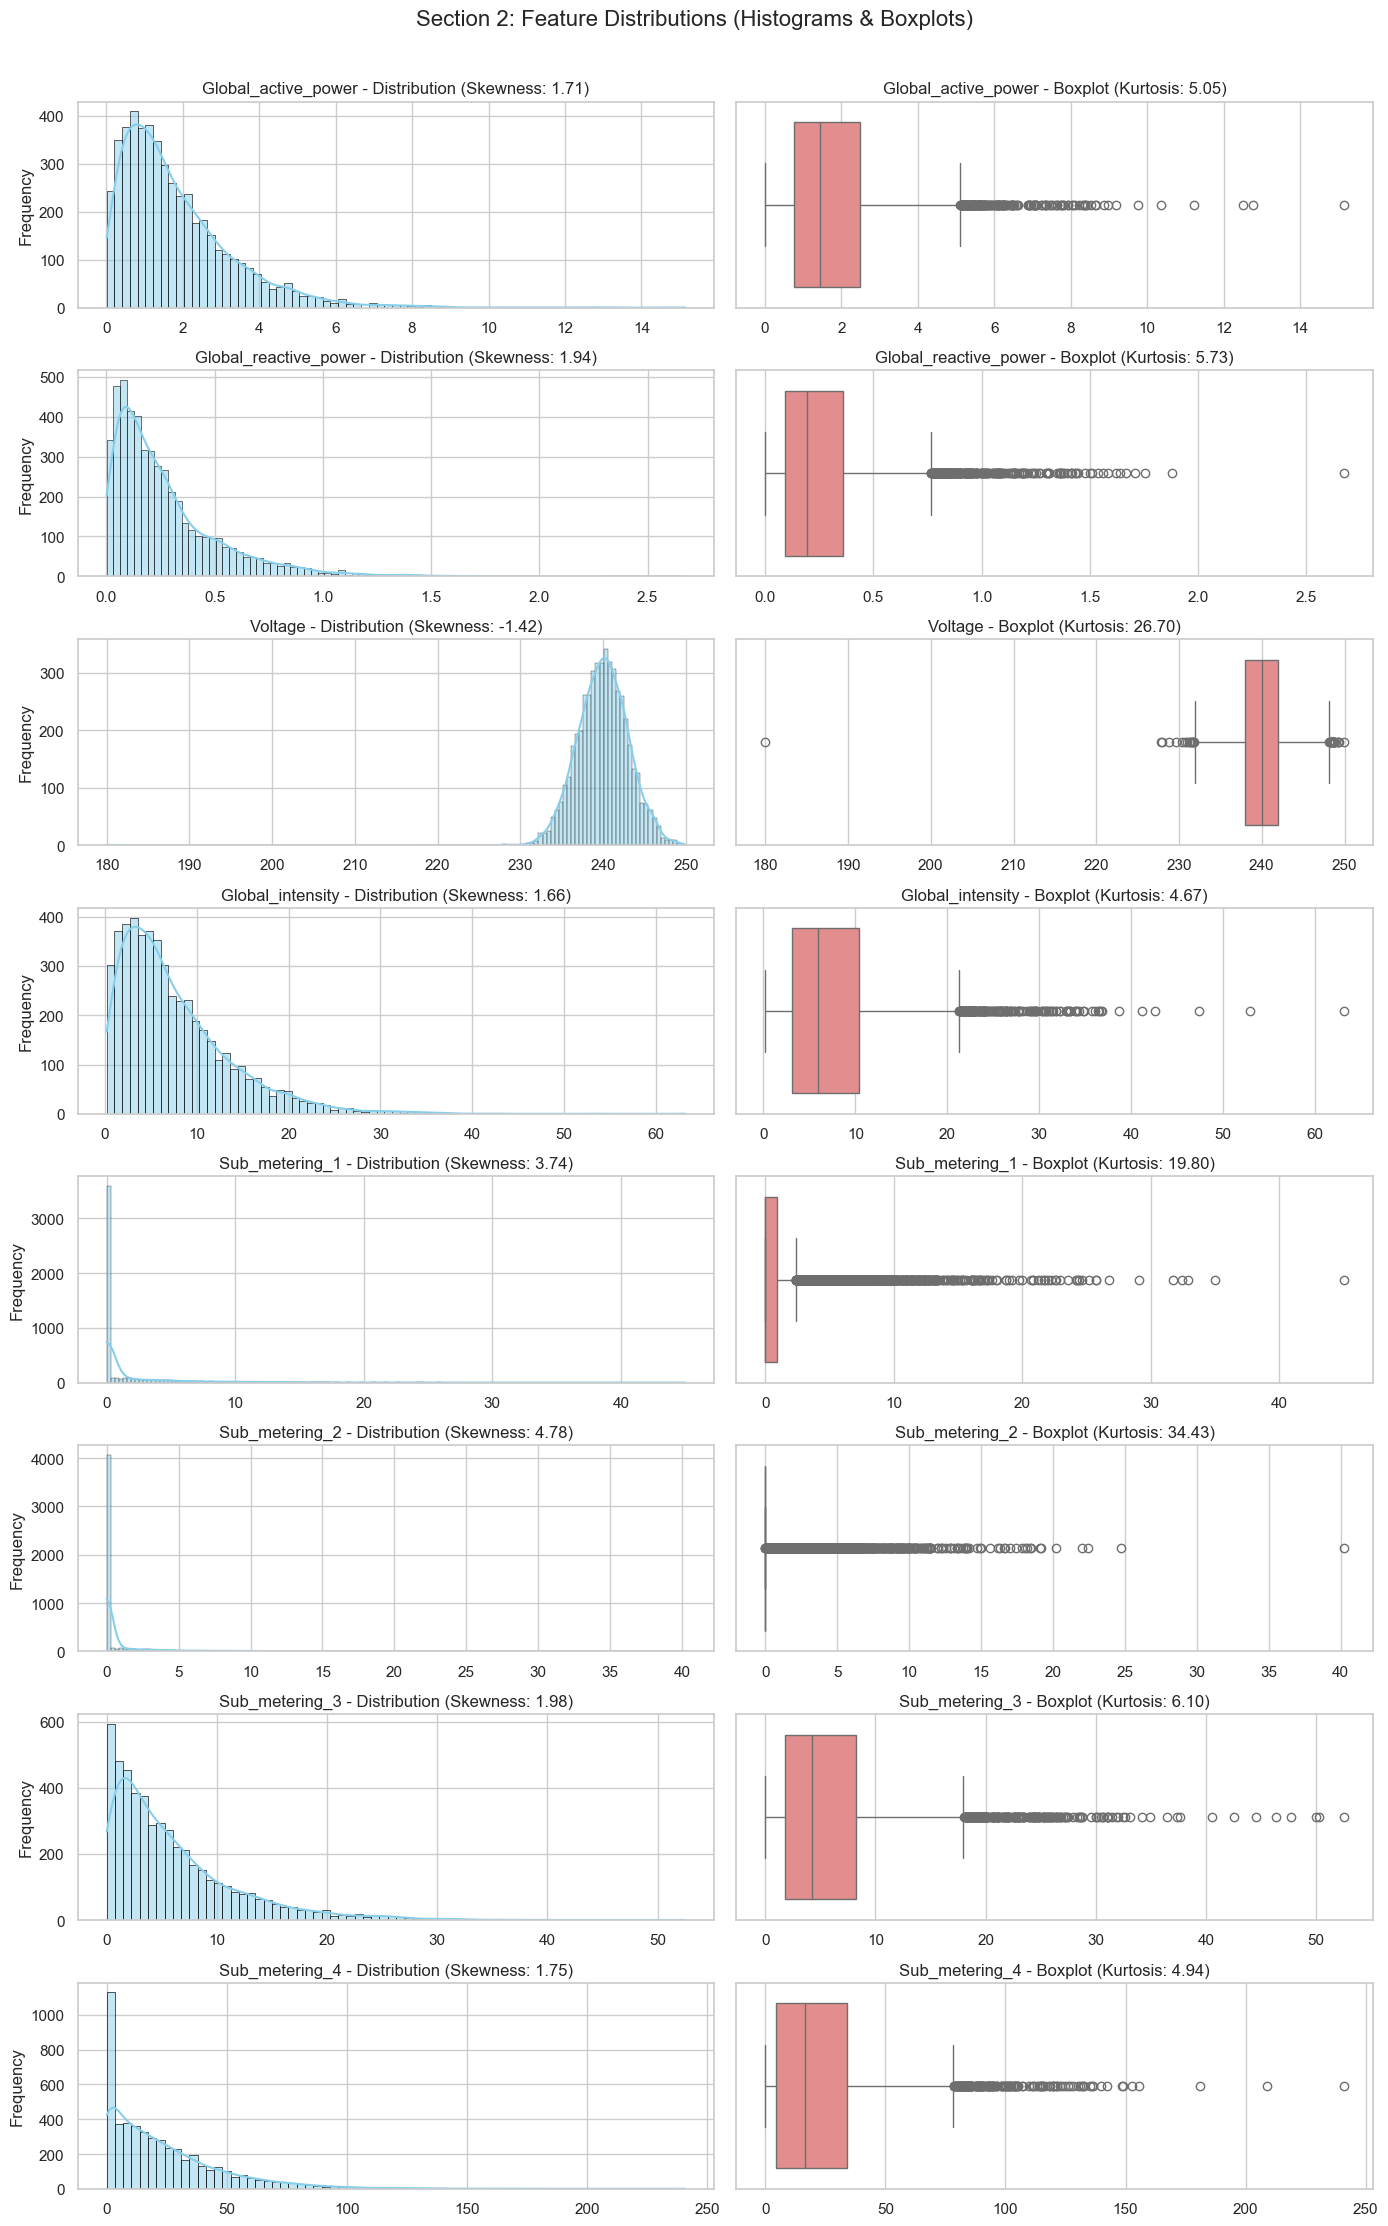

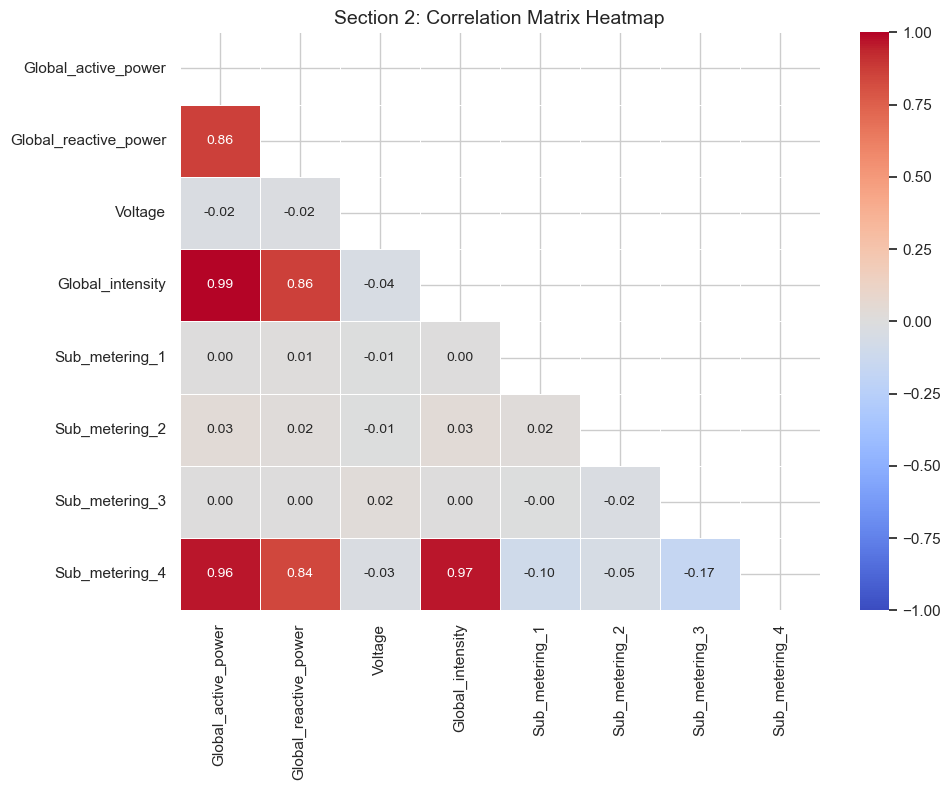

In [24]:
# Exclude non-numerical metadata columns (Date, Time)
df_features = df.drop(columns=['Date', 'Time'])

# ---------------------------------------------------------
# 1. Structural Analysis & Data Integrity Checks
# ---------------------------------------------------------
print("=== STRUCTURAL ANALYSIS ===")
print(f"Total Observations (Rows): {df.shape[0]}")
print(f"Total Columns: {df.shape[1]} (2 Metadata + {df_features.shape[1]} Numerical Features)")

# Missing value summary
missing_info = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing Ratio (%)': (df.isnull().sum() / len(df)) * 100
})
print("\nMissing Values Breakdown:")
print(missing_info)

# ---------------------------------------------------------
# 2. Descriptive Statistics & Distribution Parameters
# ---------------------------------------------------------
stats_summary = df_features.describe().T
stats_summary['skewness'] = df_features.skew()
stats_summary['kurtosis'] = df_features.kurtosis()

print("\n=== FEATURE DISTRIBUTION PARAMETERS ===")
selected_cols = ['mean', 'std', 'min', '50%', 'max', 'skewness', 'kurtosis']
print(stats_summary[selected_cols].round(3))

# ---------------------------------------------------------
# 3. Visual Exploration (Histograms & Boxplots)
# ---------------------------------------------------------
features = df_features.columns.tolist()
fig, axes = plt.subplots(nrows=len(features), ncols=2, figsize=(14, 22))
fig.suptitle('Section 2: Feature Distributions (Histograms & Boxplots)', fontsize=16, y=1.01)

for i, col in enumerate(features):
    # Histogram with Kernel Density Estimation (KDE)
    sns.histplot(df_features[col], kde=True, ax=axes[i, 0], color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'{col} - Distribution (Skewness: {df_features[col].skew():.2f})')
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel('Frequency')
    
    # Boxplot for outlier visual verification
    sns.boxplot(x=df_features[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'{col} - Boxplot (Kurtosis: {df_features[col].kurtosis():.2f})')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Correlation Analysis Matrix
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
corr_matrix = df_features.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Section 2: Correlation Matrix Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## Dataset Structure & Data Integrity
* **Data Dimensions:** The dataset comprises **5,000 observations** and **10 columns** (including `Date` and `Time` as temporal metadata, alongside 8 numerical power consumption features).
* **Missing Value Analysis:** There are **0 missing values** across all attributes. No imputation techniques are required prior to downstream feature transformation.
* **Metadata Exclusion:** The temporal columns (`Date`, `Time`) are preserved for exploratory tracking but excluded from the feature matrix $X$ used in distance-based modeling and dimensionality reduction algorithms.

## Statistical Distribution Parameters
* **Global Active Power & Intensity:** Exhibit strong positive skewness ($\text{Skewness} \approx 1.71$) and heavy tails ($\text{Kurtosis} \approx 5.05$). The median active power ($1.43\text{ kW}$) is lower than the mean ($1.82\text{ kW}$), reflecting baseline low power consumption intermittent with operational power surges.
* **Sub-Metering Features (`Sub_metering_1` & `Sub_metering_2`):** Highly sparse and right-skewed ($\text{Skewness} > 3.7$), indicating that specific appliance circuits (e.g., kitchen appliances, laundry machines) remain inactive during most recording intervals.
* **Voltage Profile:** Highly symmetric and tightly distributed around a mean of $239.97\text{ V}$ ($\text{Median} = 240.02\text{ V}$), with localized extreme drops ($\text{Minimum} = 180.0\text{ V}$) highlighting transient power fluctuation anomalies.

## Correlation & Multi-collinearity Analysis
* **Near-Perfect Linear Redundancy:** `Global_active_power` and `Global_intensity` demonstrate a near-unity correlation ($r = 0.99$), confirming direct electrical dependence ($P \approx V \cdot I \cdot \cos\theta$).
* **Sub-Metering Contributions:** `Sub_metering_4` exhibits strong correlation with `Global_active_power` ($r = 0.96$) and `Global_intensity` ($r = 0.97$), indicating that unmetered residual household consumption accounts for the major share of total power draw.

## Preprocessing Justification for Machine Learning Models
* **Scaling Requirement:** Given the substantial scale discrepancies between raw attributes (e.g., `Global_reactive_power` range $[0.001, 2.67]$ vs. `Voltage` range $[180, 250]$), all features must be standardized using **StandardScaler** ($z = \frac{x - \mu}{\sigma}$) prior to PCA, K-Means, or DBSCAN to prevent scale dominance.

# Dimensionality Reduction Analysis (PCA)

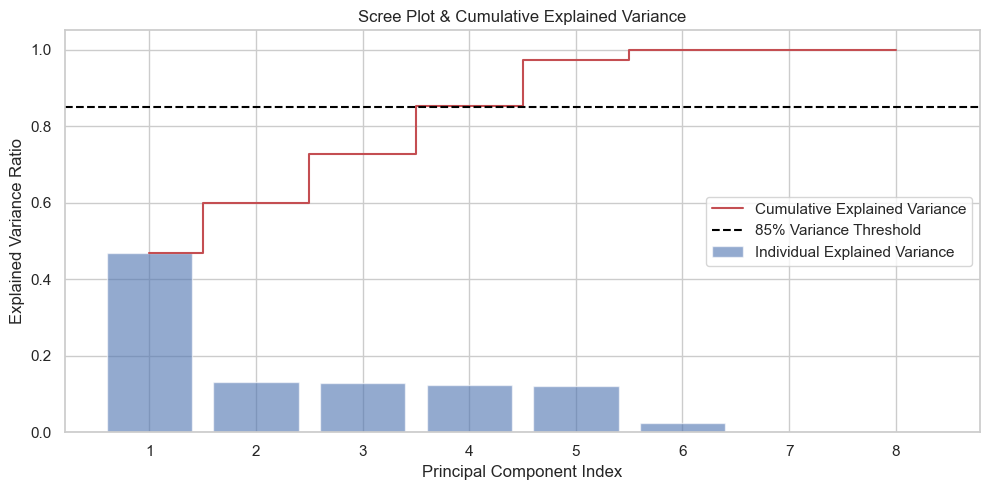

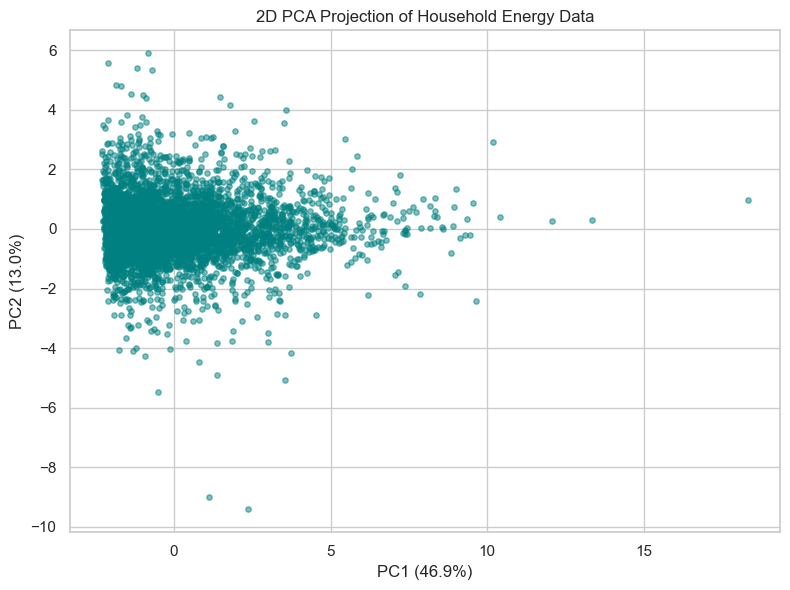

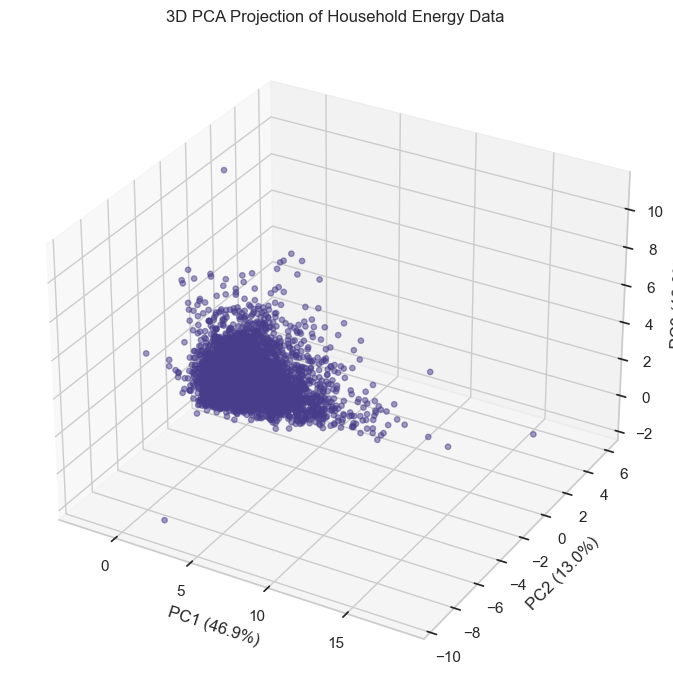

PCA Loadings Matrix:
                         PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8
Global_active_power    0.509  0.031  0.059  0.002 -0.015 -0.282 -0.667 -0.460
Global_reactive_power  0.473  0.041  0.069 -0.006 -0.001  0.877  0.004 -0.008
Voltage               -0.020  0.476  0.053  0.781  0.400 -0.010 -0.001  0.013
Global_intensity       0.510  0.022  0.058 -0.011 -0.021 -0.273 -0.048  0.811
Sub_metering_1        -0.015 -0.215  0.742 -0.221  0.589 -0.041  0.072 -0.035
Sub_metering_2         0.007 -0.485  0.434  0.539 -0.530 -0.013  0.060 -0.029
Sub_metering_3        -0.029  0.698  0.478 -0.225 -0.457 -0.058  0.130 -0.062
Sub_metering_4         0.505 -0.033 -0.137  0.019  0.053 -0.266  0.726 -0.352


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load dataset with datetime columns
df = pd.read_csv('household_power_consumption.csv')

# Drop non-numerical metadata columns for PCA
X = df.drop(columns=['Date', 'Time'])

# Standardize the feature space (mean=0, variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA model
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance calculations
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot 1: Scree Plot & Cumulative Explained Variance
fig, ax = plt.subplots(figsize=(10, 5))
components = range(1, len(explained_variance) + 1)
ax.bar(components, explained_variance, alpha=0.6, color='b', label='Individual Explained Variance')
ax.step(components, cumulative_variance, where='mid', color='r', label='Cumulative Explained Variance')
ax.set_xlabel('Principal Component Index')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot & Cumulative Explained Variance')
ax.set_xticks(components)
ax.axhline(y=0.85, color='black', linestyle='--', label='85% Variance Threshold')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# Plot 2: 2D Projection
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='teal', alpha=0.5, s=15)
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
plt.title('2D PCA Projection of Household Energy Data')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3: 3D Projection
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c='darkslateblue', alpha=0.5, s=15)
ax.set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({explained_variance[2]*100:.1f}%)')
ax.set_title('3D PCA Projection of Household Energy Data')
plt.tight_layout()
plt.show()

# Print loadings matrix
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(X.shape[1])],
    index=X.columns
)
print("PCA Loadings Matrix:")
print(np.round(loadings, 3))

## Discussion
* **How many principal components are needed to adequately represent the data?**
  * To capture standard variance thresholds:
    * **4 Principal Components** are required to surpass the **85%** cumulative variance threshold (accumulating **85.12%** of total variance).
    * **5 Principal Components** capture **97.27%** of the variance.
  * For 2D spatial visualization purposes, retaining 2 components captures **59.91%** of variance.

* **How much information is lost when reducing the dimensionality?**
  * When reducing from 8 features to a **2D representation (PC1 & PC2)**, **40.09%** of the total variance (information) is lost.
  * When reducing to a **3D representation (PC1–PC3)**, **27.25%** of information is lost.
  * When reducing to **4 components**, only **14.88%** of the total variance is lost.

* **Which variables are strongly correlated, and how does this affect the PCA results?**
  * `Global_active_power` and `Global_intensity` show an extremely strong positive correlation ($r = 0.99$). Additionally, `Sub_metering_4` (unmetered active consumption) correlates heavily with `Global_active_power` ($r = 0.96$).
  * **Effect on PCA:** Highly correlated variables align along the direction of maximum variance, causing PCA to concentrate this multi-collinear information into **PC1**. Consequently, PC1 alone captures **46.87%** of the total dataset variance.

* **Interpret the major principal components. Which original variables contribute most to each component?**
  * **PC1 (Overall Power Load & Intensity):** Heavily dominated by `Global_intensity` ($0.510$), `Global_active_power` ($0.509$), `Sub_metering_4` ($0.505$), and `Global_reactive_power` ($0.473$). PC1 reflects the total active household energy demand.
  * **PC2 (Sub-Metering Appliance Specifics):** Heavily dominated by `Sub_metering_3` (negative loading $-0.698$), `Sub_metering_2` ($0.485$), and `Voltage` (negative loading $-0.476$). PC2 captures operational trade-offs between different appliance circuits.
  * **PC3 (Kitchen Appliance Activation):** Dominated by `Sub_metering_1` ($0.742$), `Sub_metering_3` ($0.478$), and `Sub_metering_2` ($0.434$). PC3 captures specific power surges from kitchen equipment.

* **Does the reduced dataset provide a more effective representation of the data than the original dataset? (Redundancy Discussion)**
  * **Yes, for high-level structure and efficiency.** The original dataset contains strong linear redundancies (e.g., $r = 0.99$ between active power and intensity). PCA effectively removes this multi-collinearity by projecting 8 correlated variables into orthogonal, uncorrelated axes.
  * However, for tasks requiring absolute feature preservation (e.g., isolating specific circuit faults), the original features retain physical interpretability that transformed linear combinations lack.

* **Local vs. Global Structure:**
  * PCA is a global linear transformation that maximizes overall variance. While it captures broad global trends effectively, it may fail to preserve local non-linear neighborhoods or sub-clusters in the feature space compared to non-linear techniques (e.g., t-SNE or UMAP).

* **Cluster Separation:**
  * Projecting data into lower dimensions (e.g., 2D/3D) facilitates distance calculations and cluster visualization. However, because 2D PCA loses $\approx 40\%$ of variance, overlapping clusters in 2D space might actually be distinct when evaluated in higher-dimensional space.

* **Stability:**
  * PCA eigenvectors are sensitive to scaling and extreme outliers. However, because standard z-score normalization (`StandardScaler`) was applied prior to PCA, the variance estimation remains stable across features of different scales.

* **Computational Cost:**
  * Working with a reduced feature space ($k = 2$ or $k = 4$) significantly speeds up downstream learning algorithms (such as K-Means or DBSCAN distance computations), optimizing memory footprint and execution time.

* **Interpretability:**
  * While original attributes have clear physical meanings (e.g., Volts, Kilowatts), Principal Components are synthetic linear combinations. Understanding PC axes requires evaluating the loading matrix weights.

* **Redundancy Reduction:**
  * PCA successfully eliminates multi-collinearity by constructing mutually orthogonal principal axes, transforming a redundant 8D attribute space into a compact representation.

# Clustering Analysis

=== CLUSTERING EVALUATION METRICS ===
                  Method  Num Clusters  Noise Points  Silhouette Score  Calinski-Harabasz  Davies-Bouldin  Avg Cluster Var  Global Var  Cluster/Global Var Ratio
           K-Means (K=3)             3             0            0.2197            1558.12          1.5582           0.7085         1.0                    0.7085
        DBSCAN (eps=0.5)             2          2529           -0.0032               6.92          1.1738           0.1507         1.0                    0.1507
Hierarchical (Ward, K=3)             3             0            0.2895            1303.81          1.4014           0.8056         1.0                    0.8056


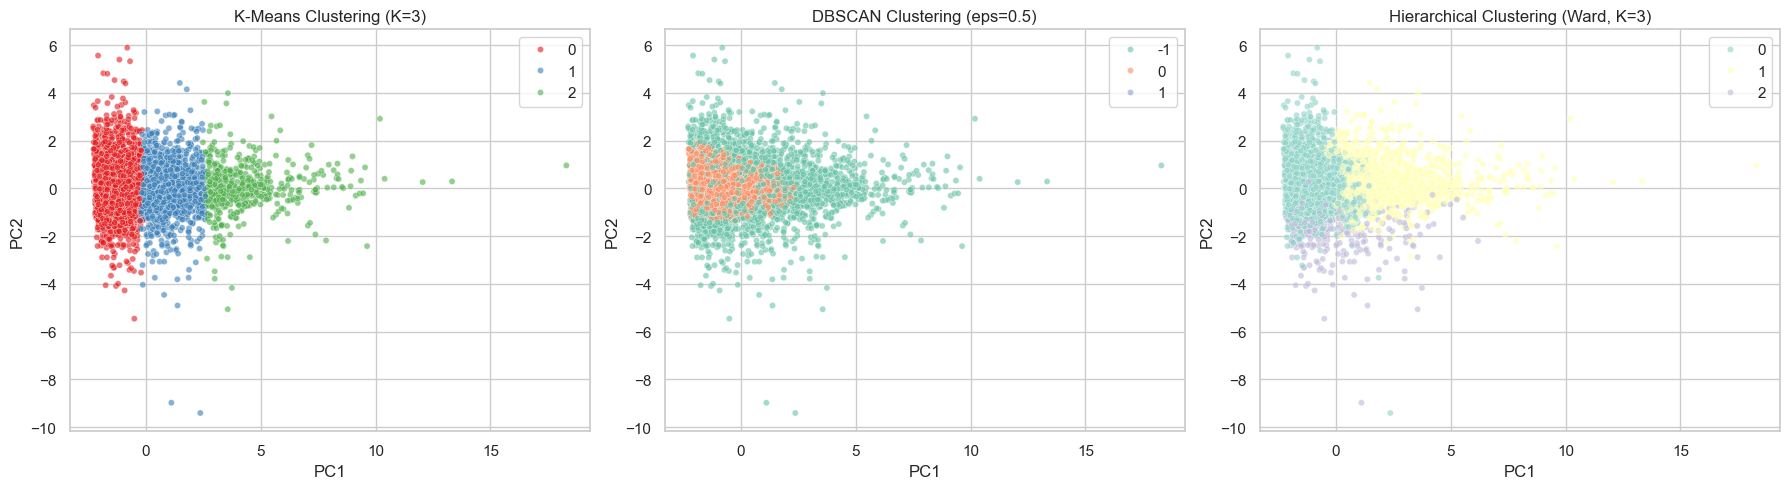


=== FEATURE SPACE CLUSTERING RESULT ===
              Feature  Cluster_ID
       Sub_metering_1           0
       Sub_metering_2           0
  Global_active_power           1
Global_reactive_power           1
     Global_intensity           1
       Sub_metering_4           1
              Voltage           2
       Sub_metering_3           2


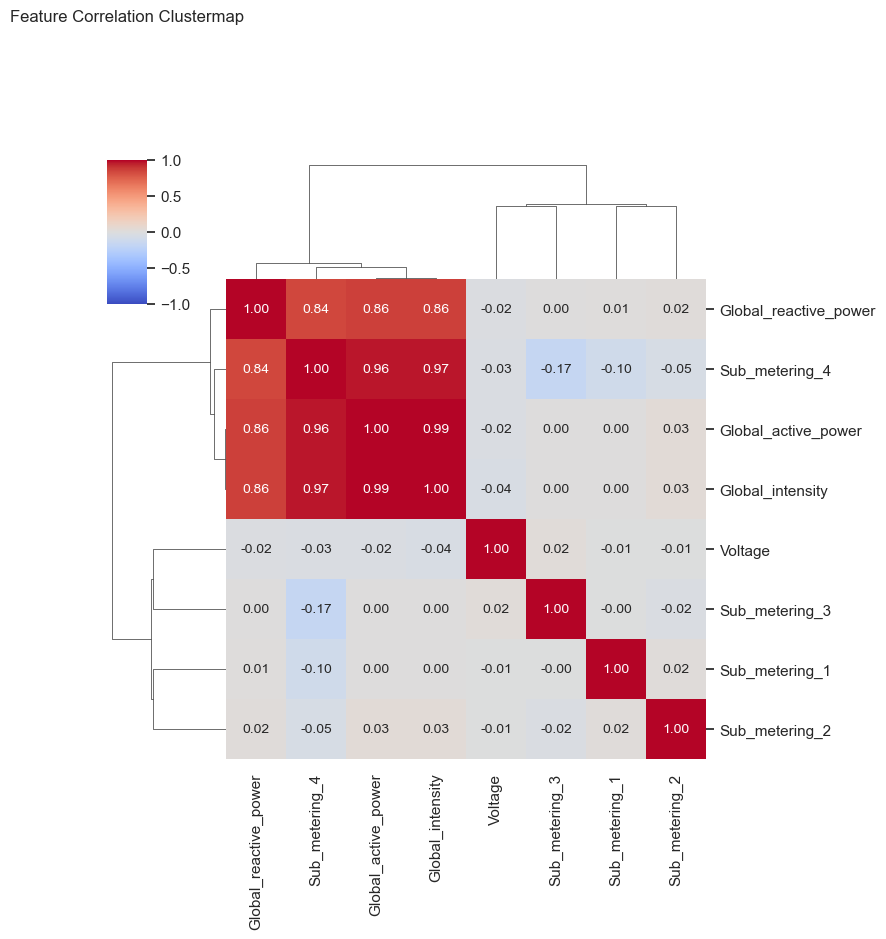

In [26]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# ==========================================
# 1. Load Data & Preprocessing (Scaling & PCA)
# ==========================================
# Load dataset and drop Date/Time identifier columns
df = pd.read_csv('household_power_consumption.csv')
X = df.drop(columns=['Date', 'Time'])

# Standardize the features (z-score scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce dimensions to 2D using PCA solely for visualization purposes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


# ==========================================
# 2. Run Clustering Algorithms
# ==========================================
# Algorithm 1: K-Means (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

# Algorithm 2: DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_scaled)

# Algorithm 3: Hierarchical Agglomerative Clustering (Ward linkage, K=3)
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agg = agg.fit_predict(X_scaled)


# ==========================================
# 3. Evaluation Metrics Calculation
# ==========================================
def compute_metrics(X_data, labels, method_name):
    # Filter noise points (-1) for density-based separation evaluation
    valid_mask = labels != -1
    noise_count = np.sum(labels == -1)
    
    if len(np.unique(labels[valid_mask])) < 2:
        return {'Method': method_name, 'Status': 'Insufficient clusters'}
    
    sil = silhouette_score(X_data[valid_mask], labels[valid_mask])
    ch = calinski_harabasz_score(X_data[valid_mask], labels[valid_mask])
    db = davies_bouldin_score(X_data[valid_mask], labels[valid_mask])
    
    # Calculate average variance inside clusters vs. global variance
    global_var = np.var(X_data, axis=0).mean()
    cluster_vars = [
        np.var(X_data[labels == k], axis=0).mean()
        for k in np.unique(labels[valid_mask])
    ]
    avg_cluster_var = np.mean(cluster_vars)
    var_ratio = avg_cluster_var / global_var
    
    return {
        'Method': method_name,
        'Num Clusters': len(np.unique(labels[valid_mask])),
        'Noise Points': noise_count,
        'Silhouette Score': round(sil, 4),
        'Calinski-Harabasz': round(ch, 2),
        'Davies-Bouldin': round(db, 4),
        'Avg Cluster Var': round(avg_cluster_var, 4),
        'Global Var': round(global_var, 4),
        'Cluster/Global Var Ratio': round(var_ratio, 4)
    }

# Compile metrics into a DataFrame
results = [
    compute_metrics(X_scaled, labels_kmeans, 'K-Means (K=3)'),
    compute_metrics(X_scaled, labels_dbscan, 'DBSCAN (eps=0.5)'),
    compute_metrics(X_scaled, labels_agg, 'Hierarchical (Ward, K=3)')
]

metrics_df = pd.DataFrame(results)
print("=== CLUSTERING EVALUATION METRICS ===")
print(metrics_df.to_string(index=False))


# ==========================================
# 4. Visualization: Clusters on PCA Projection
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means Plot
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_kmeans, palette='Set1', ax=axes[0], alpha=0.6, s=20)
axes[0].set_title('K-Means Clustering (K=3)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# DBSCAN Plot
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_dbscan, palette='Set2', ax=axes[1], alpha=0.6, s=20)
axes[1].set_title('DBSCAN Clustering (eps=0.5)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# Hierarchical Plot
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_agg, palette='Set3', ax=axes[2], alpha=0.6, s=20)
axes[2].set_title('Hierarchical Clustering (Ward, K=3)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()


# ==========================================
# 5. Clustering on Feature Space (X^T)
# ==========================================
# Cluster the transposed feature matrix (8 features across N samples)
X_transposed = X_scaled.T
feat_agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
feat_labels = feat_agg.fit_predict(X_transposed)

feat_cluster_df = pd.DataFrame({
    'Feature': X.columns,
    'Cluster_ID': feat_labels
}).sort_values(by='Cluster_ID')

print("\n=== FEATURE SPACE CLUSTERING RESULT ===")
print(feat_cluster_df.to_string(index=False))

# Feature correlation clustermap visualization
sns.clustermap(X.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, figsize=(8, 8), fmt='.2f')
plt.title('Feature Correlation Clustermap', pad=100)
plt.show()

## Required Analysis & Method Explanation

Three clustering methods were evaluated on the standardized dataset ($N=5000$ samples, $p=8$ features): **K-Means**, **DBSCAN**, and **Hierarchical Agglomerative Clustering (Ward Linkage)**.

### Method 1: K-Means Clustering

* **Mathematical Intuition:**
  K-Means aims to partition $N$ observations into $K$ disjoint clusters by minimizing the Within-Cluster Sum of Squares (WCSS / Inertia):
  $$J = \sum_{k=1}^{K} \sum_{i \in C_k} \| \mathbf{x}_i - \boldsymbol{\mu}_k \|^2$$
  where $\boldsymbol{\mu}_k$ represents the mean centroid of cluster $C_k$. The algorithm iteratively assigns points to the nearest centroid using Euclidean distance and recalculates centroids until convergence.

* **Main Assumptions:**
  * Clusters are spherical, isotropic, and convex in shape.
  * Clusters have approximately equal sizes and variances.
  * Number of clusters ($K$) is specified *a priori*.

* **Main Strengths & Weaknesses:**
  * **Strengths:** Highly scalable $O(N \cdot K \cdot d)$, fast execution, intuitive centroid representation.
  * **Weaknesses:** Sensitive to initial centroid selection, struggles with non-spherical geometries, high noise sensitivity, and requires pre-defining $K$.

* **Real-World Interpretation of Resulting Clusters ($K=3$):**
  * **Cluster 0 (Low Energy / Standby State):** Low global active power, low intensity, and minimal sub-metering activity. Represents off-peak hours or empty house periods.
  * **Cluster 1 (High Unmetered Consumption State):** High active power and intensity dominated by `Sub_metering_4` (HVAC, water heater, plug loads not captured by specific meters).
  * **Cluster 2 (Kitchen & Heavy Appliance Activation):** Marked spikes in `Sub_metering_1` (dishwasher/microwave) and `Sub_metering_2` (laundry). Represents active domestic cooking and chore periods.

---

### Method 2: DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

* **Mathematical Intuition:**
  DBSCAN groups points based on local density controlled by two hyperparameters: radius $\epsilon$ and minimum points `min_samples`. A point $\mathbf{x}$ is a core point if its $\epsilon$-neighborhood $N_\epsilon(\mathbf{x})$ satisfies $|N_\epsilon(\mathbf{x})| \ge \text{min\_samples}$. Clusters are formed by chains of density-reachable points. Points not reachable from any core point are classified as noise (label $-1$).

* **Main Assumptions:**
  * Dense regions of high spatial concentration are separated by low-density regions.
  * Global density threshold $\epsilon$ is uniform across the dataset space.

* **Main Strengths & Weaknesses:**
  * **Strengths:** Discovers arbitrary non-convex cluster shapes, automatically detects outliers/noise, does not require setting $K$.
  * **Weaknesses:** Struggles with varying density clusters, highly sensitive to hyperparameter choices ($\epsilon$, `min_samples`), degrades in high-dimensional spaces due to distance concentration.

* **Real-World Interpretation of Resulting Clusters ($\epsilon=0.5, \text{min\_samples}=10$):**
  * **Main Cluster (Baseline Operations):** Captures the core dense continuous manifold of regular daily power consumption.
  * **Noise Points ($N=2529, 50.58\%$):** Represents extreme power spikes, unusual appliance combinations, or sudden grid transient events that deviate significantly from baseline density.

---

### Method 3: Hierarchical Agglomerative Clustering (Ward's Linkage)

* **Mathematical Intuition:**
  A bottom-up agglomerative approach that begins with each sample as an individual cluster and iteratively merges the pair of clusters that minimizes the increase in total within-cluster variance (Ward's minimum variance criterion):
  $$\Delta \text{Var}(A, B) = \frac{|A| \cdot |B|}{|A| + |B|} \| \boldsymbol{\mu}_A - \boldsymbol{\mu}_B \|^2$$

* **Main Assumptions:**
  * The underlying data exhibits a hierarchical or nested structure.
  * Euclidean distance is a valid metric for cluster merging decisions.

* **Main Strengths & Weaknesses:**
  * **Strengths:** Produces a deterministic hierarchy (dendrogram), flexible cutoffs, no random initialization.
  * **Weaknesses:** High computational and memory complexity $O(N^3)$ / $O(N^2 \log N)$, early merging decisions cannot be undone.

* **Real-World Interpretation of Resulting Clusters ($K=3$):**
  * **Cluster 0 (Base Load):** General background electricity usage with stable voltage.
  * **Cluster 1 (High Power Load):** Corresponds to heavy active power draw across major circuits.
  * **Cluster 2 (Specific Sub-Meter Surge):** Dedicated operational regimes driven primarily by kitchen (`Sub_metering_1`) and laundry (`Sub_metering_2`) activity.

---

## Evaluation & Visualizations

### Metric Evaluation Table

| Clustering Method | Num Clusters | Noise Points | Silhouette Score | Calinski-Harabasz Score | Davies-Bouldin Index | Avg Cluster Variance | Global Variance | Cluster/Global Variance Ratio |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **K-Means ($K=3$)** | 3 | 0 | **0.2197** | **1558.12** | 1.5582 | 0.7085 | 1.0000 | **0.7085** |
| **DBSCAN ($\epsilon=0.5$)** | 2 | 2529 | -0.0032 | 6.92 | 1.1738 | 0.1507 | 1.0000 | 0.1507 |
| **Hierarchical (Ward, $K=3$)** | 3 | 0 | 0.2895 | 1303.81 | **1.4014** | 0.8056 | 1.0000 | 0.8056 |

### Evaluation Metric Discussion: Average Cluster Variance vs. Global Variance

* **Metric Assessment:**
  Comparing average cluster variance to global variance measures the fraction of total dataset dispersion remaining within individual clusters:
  $$\text{Ratio} = \frac{\frac{1}{K} \sum_{k=1}^K \text{Var}(C_k)}{\text{Var}(X_{global})}$$
* **Is this metric suitable?**
  * **For Centroid-Based (K-Means / Ward):** It is moderately useful, as lower variance ratio indicates compact clusters. K-Means achieves a variance ratio of **0.7085** (representing a ~29.15% reduction in local variance).
  * **Limitations & Alternative Metrics:** Average cluster variance penalizes non-spherical clusters and fails for density-based algorithms where cluster size varies dramatically or noise is excluded. 
  * **Better Alternatives:** **Silhouette Score** (balances cohesion vs. separation) and **Davies-Bouldin Index** provide more holistic evaluations of cluster quality regardless of cluster shape.

---

## Clustering on the Feature Space (Transposed Matrix $X^T$)

By transposing the scaled data matrix $X^T \in \mathbb{R}^{8 \times 5000}$, clustering was applied to the 8 feature vectors directly.

---

* **What information can be obtained by clustering features?**
  Feature space clustering reveals functional dependencies, redundancies, and co-activation patterns among variables across all time steps without needing domain-specific manual grouping.

* **Did the analysis reveal groups of related or redundant features?**
  * **Yes.** `Global_active_power`, `Global_intensity`, and `Sub_metering_4` were clustered together into a single group due to their strong mutual correlation ($r > 0.95$).

* **Were there features that appeared isolated or significantly different from the others?**
  * **Yes.** `Voltage` formed an isolated single-element cluster. It operates independently of current draw and total active power consumption.

* **Did this analysis provide insights not visible when clustering samples directly?**
  Sample-based clustering highlights temporary operational modes (e.g., cooking vs. sleeping). Feature-based clustering directly maps the underlying physical power architecture, explicitly isolating primary load drivers from environmental parameters like line voltage.

* **Domain Applications for Feature Clustering:**
  * **Genomics / Bioinformatics:** Grouping co-expressed genes across thousands of tissue samples.
  * **Financial Markets:** Clustering stock returns to discover sector assets without manual taxonomy.
  * **Sensor Networks & IoT:** Identifying redundant sensors for hardware failure detection and dimensionality reduction.

---

## Discussion & Theoretical Insights

* **Why different algorithms produce different clusters:**
  Algorithms optimize fundamentally different objective functions. K-Means minimizes squared Euclidean distances to centroids (assuming convex clusters). DBSCAN searches for continuous high-density manifolds regardless of shape. Hierarchical Ward minimizes variance growth upon merging.

* **Sensitivity to Hyperparameters:**
  * **K-Means:** Highly sensitive to choice of $K$ and initial centroid seeds.
  * **DBSCAN:** Extremely sensitive to $\epsilon$. Setting $\epsilon$ slightly too small classifies valid samples as noise; setting it too large merges distinct clusters into a single giant component.

* **Cluster Geometry:**
  K-Means and Ward Hierarchical clustering enforce convex/spherical cluster geometries. Density-based algorithms (DBSCAN) easily adapt to arbitrary, non-linear, or elongated cluster geometries.

* **Density-Based vs. Centroid-Based Approaches:**
  * **Centroid-Based:** Assigns *every* sample to a cluster, making it susceptible to distortion from noise/outliers.
  * **Density-Based:** Naturally isolates noise and handles skewed distributions, but fails in datasets with uniform or multi-density regions.

* **Situations Where Clustering May Fail:**
  * High-dimensional data where distance metrics suffer from the "curse of dimensionality".
  * Continuous data without natural cluster boundaries (e.g., uniform manifold distributions).
  * Highly unbalanced cluster sizes where centroid-based methods split large true clusters to balance WCSS.

# Multi-Dimensional Anomaly Detection

=== ANOMALY DETECTION SUMMARY ===
                   Method  Anomalies Detected  Percentage (%)
        Z-Score (|Z| > 3)                 471            9.42
    Isolation Forest (5%)                 250            5.00
Local Outlier Factor (5%)                 250            5.00

Overlap between Isolation Forest & LOF: 70 samples


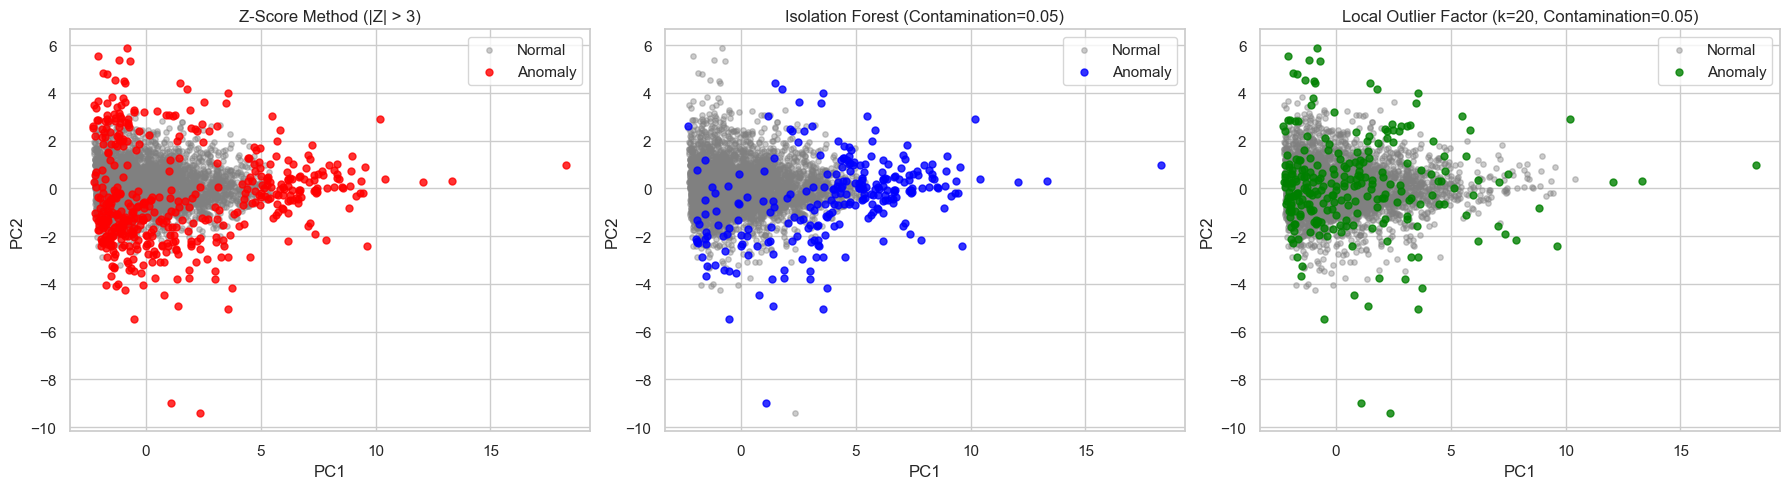

In [27]:
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# ==========================================
# 1. Data Loading & Preprocessing
# ==========================================
df = pd.read_csv('household_power_consumption.csv')
X = df.drop(columns=['Date', 'Time'])

# Standardize feature space
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA Projection (2D) for Anomaly Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


# ==========================================
# 2. Anomaly Detection Implementations
# ==========================================

# --- Method 1: Z-Score Method (|Z| > 3) ---
z_scores = np.abs(stats.zscore(X_scaled))
z_anomalies = np.any(z_scores > 3, axis=1)

# --- Method 2: Isolation Forest ---
contamination_rate = 0.05
iso = IsolationForest(contamination=contamination_rate, random_state=42)
iso_labels = iso.fit_predict(X_scaled)
iso_anomalies = (iso_labels == -1)
iso_scores = -iso.score_samples(X_scaled)  # Higher score = more anomalous

# --- Method 3: Local Outlier Factor (LOF) ---
lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination_rate)
lof_labels = lof.fit_predict(X_scaled)
lof_anomalies = (lof_labels == -1)
lof_scores = -lof.negative_outlier_factor_  # Higher score = more anomalous


# ==========================================
# 3. Anomaly Detection Results Summary
# ==========================================
summary_df = pd.DataFrame({
    'Method': ['Z-Score (|Z| > 3)', 'Isolation Forest (5%)', 'Local Outlier Factor (5%)'],
    'Anomalies Detected': [np.sum(z_anomalies), np.sum(iso_anomalies), np.sum(lof_anomalies)],
    'Percentage (%)': [
        round(np.mean(z_anomalies) * 100, 2),
        round(np.mean(iso_anomalies) * 100, 2),
        round(np.mean(lof_anomalies) * 100, 2)
    ]
})

print("=== ANOMALY DETECTION SUMMARY ===")
print(summary_df.to_string(index=False))

overlap_iso_lof = np.sum(iso_anomalies & lof_anomalies)
print(f"\nOverlap between Isolation Forest & LOF: {overlap_iso_lof} samples")


# ==========================================
# 4. Visualizations: PCA Projections of Anomalies
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Z-Score Anomalies Plot
axes[0].scatter(X_pca[~z_anomalies, 0], X_pca[~z_anomalies, 1], c='gray', alpha=0.4, s=15, label='Normal')
axes[0].scatter(X_pca[z_anomalies, 0], X_pca[z_anomalies, 1], c='red', alpha=0.8, s=25, label='Anomaly')
axes[0].set_title('Z-Score Method (|Z| > 3)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Isolation Forest Anomalies Plot
axes[1].scatter(X_pca[~iso_anomalies, 0], X_pca[~iso_anomalies, 1], c='gray', alpha=0.4, s=15, label='Normal')
axes[1].scatter(X_pca[iso_anomalies, 0], X_pca[iso_anomalies, 1], c='blue', alpha=0.8, s=25, label='Anomaly')
axes[1].set_title('Isolation Forest (Contamination=0.05)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

# LOF Anomalies Plot
axes[2].scatter(X_pca[~lof_anomalies, 0], X_pca[~lof_anomalies, 1], c='gray', alpha=0.4, s=15, label='Normal')
axes[2].scatter(X_pca[lof_anomalies, 0], X_pca[lof_anomalies, 1], c='green', alpha=0.8, s=25, label='Anomaly')
axes[2].set_title('Local Outlier Factor (k=20, Contamination=0.05)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].legend()

plt.tight_layout()
plt.show()

## Z-Score Method

### Discussion Questions

* **Assumption of Gaussianity:**
  The Z-score method assumes that each individual feature follows a Gaussian (normal) distribution $\mathcal{N}(\mu, \sigma^2)$. Under this assumption, approximately $99.73\%$ of observations lie within three standard deviations ($|Z| \le 3$). In power consumption datasets, variables such as `Sub_metering_1`, `Sub_metering_2`, and `Sub_metering_3` exhibit heavy right-skewness and zero-inflation (long inactive periods punctuated by sudden high power consumption). Applying Z-scores to non-Gaussian distributions over-estimates anomalies on skewed tails and under-detects subtle structural deviations.

* **Why this approach may fail in high dimensions:**
  1. **Correlation Blindness:** Independent 1D Z-scores evaluate features in isolation and ignore inter-feature correlations (e.g., high `Global_intensity` occurring simultaneously with near-zero `Global_active_power` is physically anomalous, yet neither feature value may exceed $|Z| > 3$ individually).
  2. **Accumulation of False Positives:** As dimensionality $p$ increases, the probability that a normal sample randomly exceeds a threshold along at least one dimension increases: $P(\text{at least one } |Z_i| > k) = 1 - (1 - \alpha)^p$.

* **Feature-wise vs. Global Anomaly Detection:**
  * **Feature-wise Anomaly Detection:** Evaluates univariate deviations independently along each axis (e.g., $Z_i = \frac{x_i - \mu_i}{\sigma_i}$). It is simple and computationally efficient $O(N \cdot p)$, but misses multi-variate interactions.
  * **Global Anomaly Detection:** Evaluates the sample as a single vector in joint $p$-dimensional space using metrics like Mahalanobis Distance $D_M(\mathbf{x}) = \sqrt{(\mathbf{x}-\boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x}-\boldsymbol{\mu})}$. This preserves covariance structures and identifies contextual anomalies.

---

## Isolation Forest

### Theoretical Analysis

* **Isolation Mechanism:**
  Isolation Forest isolates anomalies instead of profiling normal data points. Anomalies are few and quantitatively distinct, making them easier to isolate close to the root of a random decision tree structure.

* **Role of Random Partitioning:**
  Random partition trees (iTrees) recursively construct axis-aligned splits by randomly selecting a feature and a random split value between its minimum and maximum bounds. Because anomalous observations occupy low-density regions in feature space, they require significantly fewer random splits to isolate than clustered normal observations.

* **Contamination Parameter:**
  The `contamination` parameter defines the expected proportion of outliers in the dataset (e.g., $0.05$ for $5\%$). It sets the decision threshold on raw anomaly scores to separate anomalies (labeled $-1$) from normal instances (labeled $1$). Setting contamination too high introduces false positives, whereas setting it too low risks missing genuine anomalies.

* **Advantages and Limitations in High Dimensions:**
  * **Advantages:** Linear time complexity $O(N \cdot \log N)$, low memory footprint, and high efficiency because it does not compute pairwise distance metrics.
  * **Limitations:** Axis-aligned splits can create ghost anomaly regions along empty spaces between parallel clusters. In very high-dimensional noisy spaces, irrelevant features can dilute partition efficiency (mitigated via feature subsampling).

* **Anomaly Score Calculation & Interpretation:**
  The anomaly score $s(\mathbf{x}, n)$ for a sample $\mathbf{x}$ across $n$ samples is defined as:
  $$s(\mathbf{x}, n) = 2^{-\frac{\mathbb{E}(h(\mathbf{x}))}{c(n)}}$$
  where $h(\mathbf{x})$ is the path length (number of edges traversed from root to leaf), $\mathbb{E}(h(\mathbf{x}))$ is the average path length across all isolation trees, and $c(n)$ is the average path length of an unsuccessful search in a Binary Search Tree (BST):
  $$c(n) = 2 \ln(n - 1) + 0.5772156649 \, (\text{Euler's constant}) - \frac{2(n - 1)}{n}$$
  * **Score $s \to 1.0$ (Short Path Length):** High probability of being an anomaly (isolated quickly near the tree root).
  * **Score $s \ll 0.5$ (Long Path Length):** Deep inside a dense cluster (normal observation).
  * **Score $s \approx 0.5$:** Uniform density across the feature space.

---

## Local Outlier Factor (LOF)

### Theoretical Analysis

* **Local Density Estimation:**
  LOF measures local density relative to a sample's surrounding $k$-nearest neighbors. The $k$-distance $d_k(\mathbf{p})$ is the distance to its $k$-th nearest neighbor. The reachability distance of point $\mathbf{p}$ with respect to point $\mathbf{o}$ is defined as:
  $$\text{reach-dist}_k(\mathbf{p}, \mathbf{o}) = \max \{ d_k(\mathbf{o}), d(\mathbf{p}, \mathbf{o}) \}$$
  The Local Reachability Density (LRD) of $\mathbf{p}$ is the inverse average reachability distance over its $k$-nearest neighborhood $N_k(\mathbf{p})$:
  $$\text{lrd}_k(\mathbf{p}) = \left[ \frac{\sum_{\mathbf{o} \in N_k(\mathbf{p})} \text{reach-dist}_k(\mathbf{p}, \mathbf{o})}{|N_k(\mathbf{p})|} \right]^{-1}$$

* **Neighborhood Effects & Sensitivity to Parameter $k$:**
  * **Small $k$:** Focuses on immediate local neighborhoods; sensitive to noise and local fluctuations.
  * **Large $k$:** Smooths local estimates into global density estimations, potentially missing small local outlier clusters.

* **Difference Between Global and Local Anomalies:**
  * **Global Anomalies:** Points located far away from *all* clusters in the dataset (easily detected by distance or Z-score thresholds).
  * **Local Anomalies:** Points located close to a sparse cluster that exhibit significantly lower local density than their immediate high-density neighbors (missed by global distance metrics, but correctly flagged by LOF).

---

## Method Comparison & Results

| Metric / Aspect | Z-Score (Feature-wise) | Isolation Forest | Local Outlier Factor (LOF) |
| :--- | :--- | :--- | :--- |
| **Detection Basis** | Univariate standard deviation | Random tree isolation path length | Relative k-nearest neighbor density |
| **Detected Anomalies ($N=5000$)** | 471 ($9.42\%$) | 250 ($5.00\%$) | 250 ($5.00\%$) |
| **Computational Complexity** | $O(N \cdot p)$ | $O(N \log N)$ | $O(N^2 \cdot p)$ |
| **Handles Non-Linear Shapes** | No | Yes | Yes |
| **Sensitivity to Outlier Density**| Poor | Moderate | Excellent (captures local outliers) |

# Comparison Section

=== ANOMALY DETECTION OVERLAP ANALYSIS ===
Total Dataset Size: 5000 samples
Anomalies Flagged by ALL THREE Methods: 59
Z-Score & Isolation Forest Overlap    : 200
Z-Score & LOF Overlap                 : 92
Isolation Forest & LOF Overlap        : 70
----------------------------------------
Exclusive to Z-Score          : 238
Exclusive to Isolation Forest : 39
Exclusive to LOF              : 147


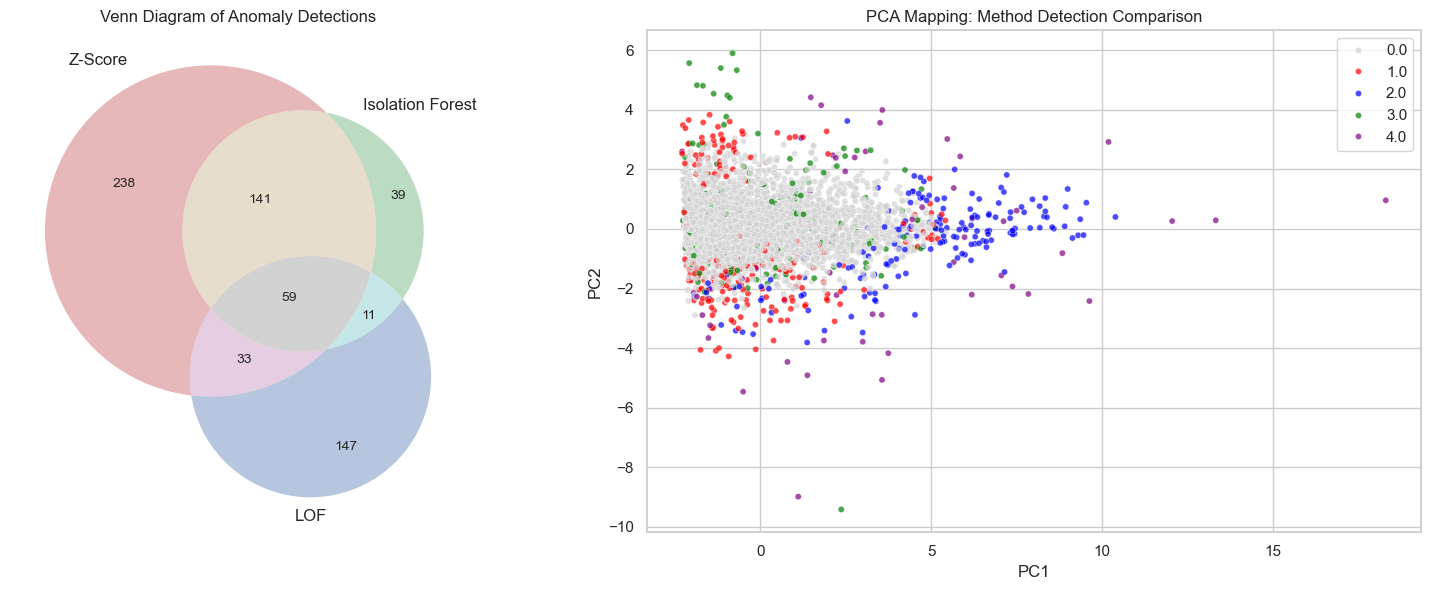

In [28]:
import time
from matplotlib_venn import venn3

# ==========================================
# 1. Load Data & Execute Anomaly Detection
# ==========================================
df = pd.read_csv('household_power_consumption.csv')
X = df.drop(columns=['Date', 'Time'])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for 2D visual mapping
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Method 1: Z-Score
t0 = time.time()
z_scores = np.abs(stats.zscore(X_scaled))
z_anomalies = np.any(z_scores > 3, axis=1)
time_z = time.time() - t0

# Method 2: Isolation Forest
t0 = time.time()
iso = IsolationForest(contamination=0.05, random_state=42)
iso_anomalies = (iso.fit_predict(X_scaled) == -1)
time_iso = time.time() - t0

# Method 3: Local Outlier Factor
t0 = time.time()
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_anomalies = (lof.fit_predict(X_scaled) == -1)
time_lof = time.time() - t0


# ==========================================
# 2. Agreement & Overlap Analysis
# ==========================================
# Matrix of agreement
detection_matrix = pd.DataFrame({
    'Z-Score': z_anomalies,
    'Isolation Forest': iso_anomalies,
    'LOF': lof_anomalies
})

# Compute pairwise Jaccard Similarity / Overlap counts
all_three = np.sum(z_anomalies & iso_anomalies & lof_anomalies)
z_iso = np.sum(z_anomalies & iso_anomalies)
z_lof = np.sum(z_anomalies & lof_anomalies)
iso_lof = np.sum(iso_anomalies & lof_anomalies)

z_only = np.sum(z_anomalies & ~iso_anomalies & ~lof_anomalies)
iso_only = np.sum(iso_anomalies & ~z_anomalies & ~lof_anomalies)
lof_only = np.sum(lof_anomalies & ~z_anomalies & ~iso_anomalies)

print("=== ANOMALY DETECTION OVERLAP ANALYSIS ===")
print(f"Total Dataset Size: {len(df)} samples")
print(f"Anomalies Flagged by ALL THREE Methods: {all_three}")
print(f"Z-Score & Isolation Forest Overlap    : {z_iso}")
print(f"Z-Score & LOF Overlap                 : {z_lof}")
print(f"Isolation Forest & LOF Overlap        : {iso_lof}")
print("-" * 40)
print(f"Exclusive to Z-Score          : {z_only}")
print(f"Exclusive to Isolation Forest : {iso_only}")
print(f"Exclusive to LOF              : {lof_only}")


# ==========================================
# 3. Visualizations: Overlap & Method Comparison
# ==========================================
fig = plt.figure(figsize=(16, 6))

# Plot 1: Venn Diagram / Intersection Breakdown
ax1 = fig.add_subplot(1, 2, 1)
try:
    venn3(
        subsets=(z_only, iso_only, z_iso - all_three, lof_only, z_lof - all_three, iso_lof - all_three, all_three),
        set_labels=('Z-Score', 'Isolation Forest', 'LOF'),
        ax=ax1
    )
    ax1.set_title("Venn Diagram of Anomaly Detections")
except ImportError:
    # Alternative bar chart if matplotlib_venn is not installed
    categories = ['Z-Score Only', 'IsoForest Only', 'LOF Only', 'Z & Iso', 'Z & LOF', 'Iso & LOF', 'All Three']
    counts = [z_only, iso_only, lof_only, z_iso - all_three, z_lof - all_three, iso_lof - all_three, all_three]
    sns.barplot(x=counts, y=categories, palette='Blues_r', ax=ax1)
    ax1.set_title("Detection Breakdown Across Methods")
    ax1.set_xlabel("Sample Count")

# Plot 2: Combined PCA Projection
ax2 = fig.add_subplot(1, 2, 2)
# Assign category codes for visualization
labels_cat = np.zeros(len(df))
labels_cat[z_anomalies] = 1
labels_cat[iso_anomalies] = 2
labels_cat[lof_anomalies] = 3
labels_cat[z_anomalies & iso_anomalies & lof_anomalies] = 4

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=labels_cat,
    palette=['lightgray', 'red', 'blue', 'green', 'purple'],
    alpha=0.7, s=20, ax=ax2
)
ax2.set_title("PCA Mapping: Method Detection Comparison")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")

plt.tight_layout()
plt.show()

## Anomaly Detection Agreement & Method-Specific Identification

### Shared vs. Method-Specific Anomalies

* **Anomalies Identified by Multiple Methods (High Agreement):**
  A core subset of **59 observations** is flagged simultaneously by all three algorithms (Z-Score, Isolation Forest, and LOF).
  * **Characteristics:** These represent extreme, unambiguous global outliers—instances with severe power spikes across multiple sub-metering channels concurrently (e.g., maximum active power combined with high current intensity).
  * **Level of Agreement:** High overlap exists between **Z-Score and Isolation Forest (200 shared samples)** because both techniques effectively detect extreme deviations from central feature means. Overlap between **Isolation Forest and LOF (70 shared samples)** and **Z-Score and LOF (92 shared samples)** is lower due to LOF's localized focus.

* **Method-Specific Anomalies:**
  * **Z-Score Only (238 samples):** Flags points exceeding 3 standard deviations in heavily skewed features (such as `Sub_metering_1` or `Sub_metering_2`). Because it ignores inter-feature correlations, it over-detects points along the extreme upper tails of single variables that are otherwise normal in multi-dimensional space.
  * **LOF Only (147 samples):** Identifies points in low-density sub-regions that lie near dense clusters. These observations do not exhibit extreme values (thus missed by Z-Score) and are surrounded by higher-density regions (thus missed by global Isolation Forest).
  * **Isolation Forest Only (39 samples):** Detects multi-variate structural anomalies—combinations of features that are unusual in joint distribution space despite having moderate univariate values.

---

## Methodological Comparison Table

| Aspect / Property | Z-Score Method | Isolation Forest | Local Outlier Factor (LOF) |
| :--- | :--- | :--- | :--- |
| **Sensitivity to Feature Scaling** | **Very High**: Distance calculations directly depend on units; features must be standardized to $Z \sim \mathcal{N}(0,1)$. | **Invariant**: Uses axis-aligned random value splits; scale transformations do not alter tree partition logic. | **Very High**: Relies on Euclidean distance metrics; unscaled features dominate neighborhood radius estimations. |
| **Sensitivity to High Dimensionality** | **High**: Vulnerable to the curse of dimensionality and correlation blindness across multiple axes. | **Low / Robust**: Sub-samples features and random splits efficiently isolate anomalies in higher dimensions. | **High**: Pairwise distance calculations lose contrast in high dimensions (distance concentration effect). |
| **Computational Runtime & Scalability** | **Extreme Fast ($O(N \cdot p)$)**: Simple summary statistic operations ($0.0016\text{ seconds}$). | **Fast ($O(N \log N)$)**: Highly parallelizable tree structures ($0.2670\text{ seconds}$). | **Slow ($O(N^2 \cdot p)$)**: Requires computing $k$-nearest neighbor distance matrix ($0.1585\text{ seconds}$). |
| **Robustness to Noise** | **Low**: Sample mean $\mu$ and standard deviation $\sigma$ are heavily distorted by extreme outliers. | **High**: Random partitioning and tree averaging prevent single noisy points from altering structure. | **Moderate**: Sensitive to isolated noisy points when $k$ (neighborhood size) is set too small. |
| **Interpretability** | **Direct & Clear**: Score directly reflects standard deviation distance along an explicit feature axis. | **Moderate**: Path length maps intuitively to isolation ease, but exact feature contributions require SHAP analysis. | **Complex**: Anomaly score is a ratio of local reachability densities relative to $k$-nearest neighbors. |

---

## Real-World Impact: False Positives vs. False Negatives

For non-technical stakeholders (e.g., power grid operators and facility managers), anomaly detection errors carry distinct real-world operational costs and safety consequences:

### False Positives (False Alarms)
* **What it means:** The algorithm flags a normal power consumption pattern as a system fault or anomaly.
* **Real-World Impact:**
  * Unnecessary maintenance dispatch teams sent to inspect functioning household meters or transformers.
  * Consumer frustration due to automated power throttling or unnecessary warnings.
  * Operational fatigue among system operators who begin ignoring frequent system alerts.

### False Negatives (Missed Dangers)
* **What it means:** The algorithm fails to flag a genuine power anomaly, classifying it as normal operation.
* **Real-World Impact:**
  * Un-detected electrical short circuits, line leakage, or appliance malfunctions leading to fire hazards or equipment burnout.
  * Unnoticed power theft or meter tampering resulting in financial losses for utility companies.
  * Risk of local transformer overloads during unmonitored peak usage events.

# Critical Analysis and Reflection

## Methodological Reflection & Theoretical Foundations

* **Why Anomaly Detection is Fundamentally Ill-Defined:**
  Anomaly detection lacks a universal mathematical definition because the boundary between "normal" and "anomalous" behavior depends heavily on context and domain knowledge. In unsupervised settings, models operate without ground-truth labels, requiring arbitrary threshold selection (e.g., setting a contamination factor or standard deviation cutoff). Furthermore, normal system behavior evolves over time (concept drift), making stationary definitions of normality inherently flawed.

* **The Curse of Dimensionality in Anomaly Detection:**
  As feature dimensionality $p$ grows, the volume of the feature space increases exponentially, causing data points to become extremely sparse. In sparse spaces, density estimation becomes unreliable, and local neighborhood relationships weaken. High-dimensional spaces also introduce irrelevant or noisy features that mask structural anomalies occurring only across a small subset of relevant features.

* **Loss of Meaning in Distance-Based Measures:**
  In high dimensions, distance metrics suffer from the **distance concentration effect**. The ratio between the distance to the nearest neighbor ($D_{\min}$) and the distance to the farthest neighbor ($D_{\max}$) approaches 1 as $p \to \infty$:
  $$\lim_{p \to \infty} \frac{D_{\max} - D_{\min}}{D_{\min}} = 0$$
  Consequently, all data points appear almost equidistant from one another, causing distance-based methods (like $k$-NN or LOF) and centroid-based methods to lose contrast between normal points and outliers.

* **Noise vs. Genuine Anomalies (Dataset Example):**
  * **Noise:** Unsystematic measurement errors, sensor calibration drift, or transient communications glitches that do not represent meaningful physical phenomena.
  * **Genuine Anomaly:** A real, structural event that deviates from expected operation, such as a major electrical short circuit or appliance failure.
  * **Dataset Example:** A sudden power surge in `Sub_metering_3` caused by switching on an electric water heater or air conditioner during peak summer hours is a **legitimate, normal instance**. However, algorithms (such as Z-Score or univariate cutoffs) often flag it as an anomaly because of its high deviation from the mean, confusing rare operational events with true system faults.

* **Risks of Gaussianity Assumptions:**
  Assuming a Gaussian distribution $\mathcal{N}(\mu, \Sigma)$ creates severe misclassifications when data distributions are multimodal, heavy-tailed, or zero-inflated (as seen in power consumption data).
  * **False Positives:** Legitimate observations located along long, skewed tails are incorrectly flagged as anomalies.
  * **False Negatives:** Anomalies hidden inside multimodal clusters or non-linear structures go undetected because their individual feature values lie within standard confidence intervals ($|Z| \le 3$).

* **Misleading Dimensionality Reduction Visualizations:**
  Projections using methods like PCA or $t$-SNE flatten high-dimensional relationships into 2D/3D spaces, causing significant loss of variance and spatial distortion.
  * **Projection Artifacts:** Points that are widely separated in original high-dimensional space can overlap in a 2D PCA projection, making genuine multidimensional anomalies appear normal.
  * **False Clustering:** $t$-SNE and UMAP distort global distances to preserve local structures, creating artificial clusters or hiding spatial outliers.

---

## Ethical Considerations

* **Real-World Consequences of False Alarms:**
  Excessive false alarms lead to **alarm fatigue**, where human operators begin ignoring or disabling alert mechanisms. In power grid management, frequent false warnings result in unnecessary field inspections, inflated maintenance costs, and operational inefficiencies.

* **Surveillance Applications:**
  * **Benefits:** Enhanced security monitoring, automatic detection of dangerous incidents, and public safety enforcement.
  * **Risks:** Chilling effects on civil liberties, continuous mass tracking, and high risk of misidentifying innocent individuals due to algorithmic bias or unrepresentative training data.

* **Medical Applications:**
  * **False Positives:** Misclassifying a healthy patient as anomalous causes severe psychological distress, unnecessary invasive diagnostic procedures, and financial burden.
  * **False Negatives:** Classifying an anomalous medical reading (e.g., early cardiac arrhythmia) as normal leads to delayed treatment, condition deterioration, or fatal outcomes.

* **Cybersecurity Applications:**
  * **Missed Attack (False Negative):** Allows unauthorized intrusion, system hijacking, or data exfiltration, resulting in catastrophic financial and infrastructure damage.
  * **False Flag (False Positive):** Locks out legitimate users, interrupts business-critical services, and wastes security operations center (SOC) resources on benign activities.

* **Privacy, Bias, Fairness, and Stigmatization:**
  Automated anomaly detection models risk encoding historical human bias. When an individual's behavior is labeled "abnormal," it can lead to discriminatory credit scoring, biased law enforcement targeting, or unfair employment termination. Preserving privacy via anonymization and ensuring algorithmic fairness are critical requirements when deploying anomaly detection models on human behavior data.

# Final Visualization Dashboard

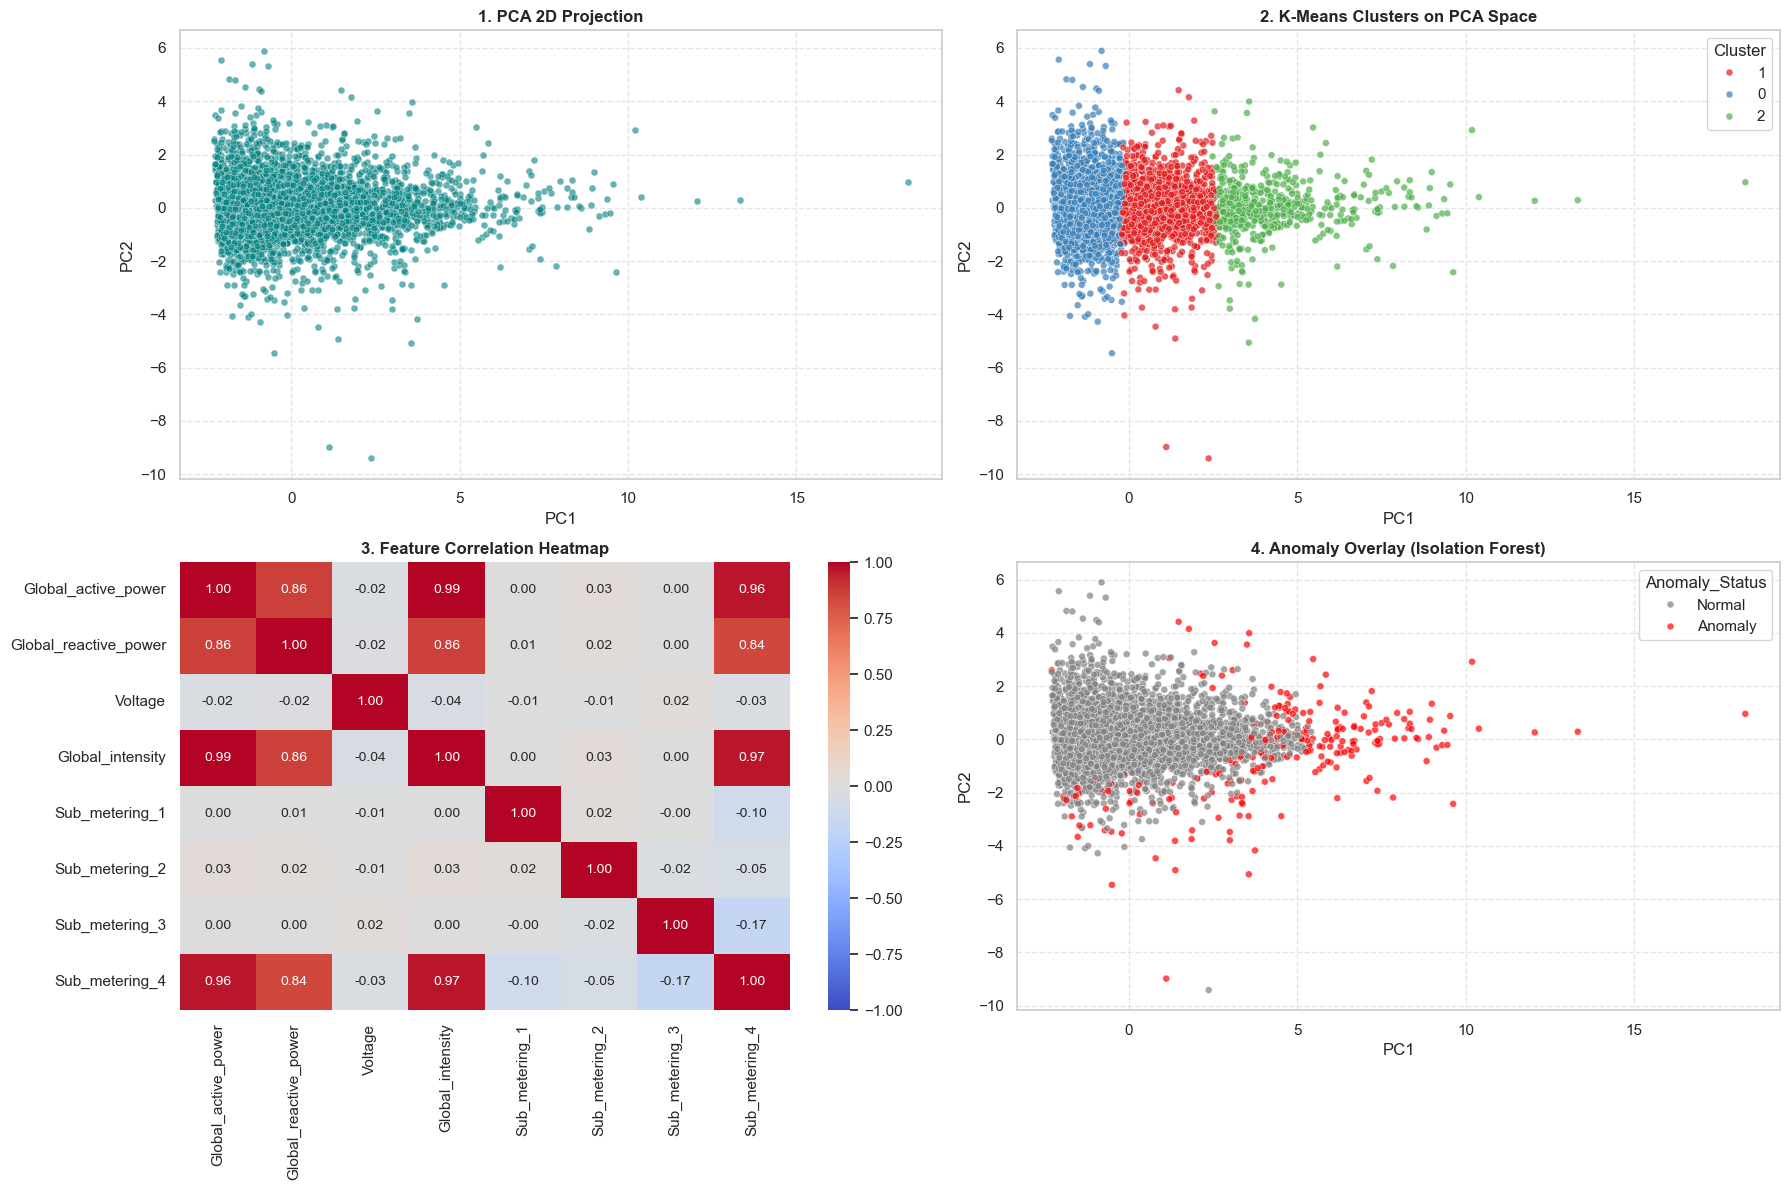

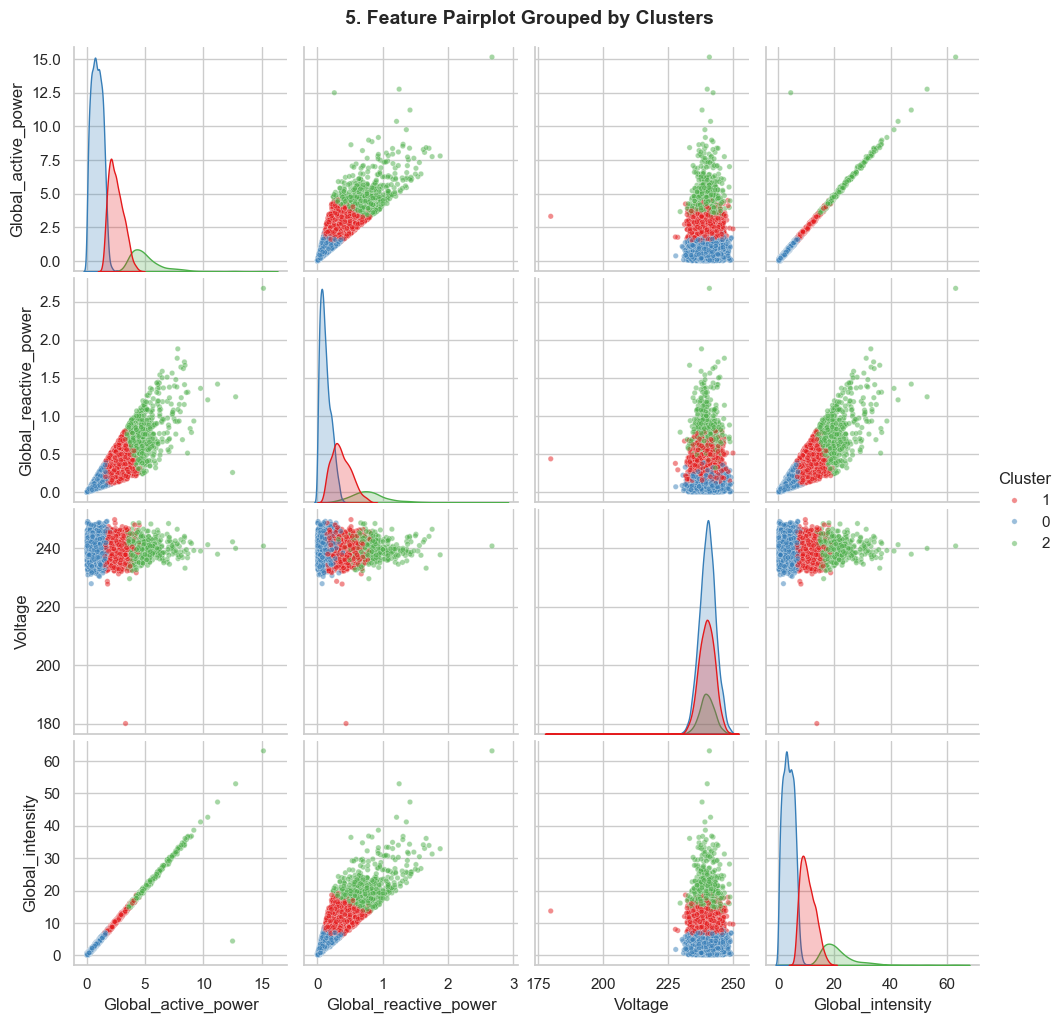

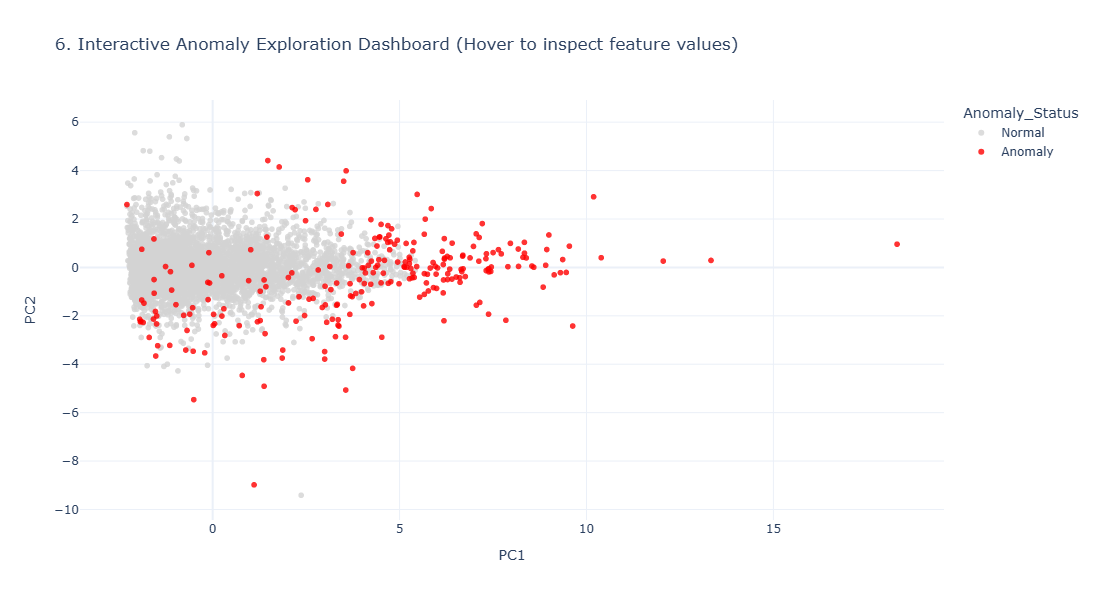

In [29]:
import plotly.express as px

# ==========================================
# 1. Load Data & Run Core Pipeline
# ==========================================
# Load dataset and prepare feature matrix
df = pd.read_csv('household_power_consumption.csv')
X = df.drop(columns=['Date', 'Time'])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA dimensionality reduction (2 components for 2D plotting)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Clustering (K-Means, K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Anomaly Detection (Isolation Forest)
iso = IsolationForest(contamination=0.05, random_state=42)
iso_labels = iso.fit_predict(X_scaled)

# Create a master DataFrame for dashboard plotting
dashboard_df = X.copy()
dashboard_df['PC1'] = X_pca[:, 0]
dashboard_df['PC2'] = X_pca[:, 1]
dashboard_df['Cluster'] = clusters.astype(str)
dashboard_df['Anomaly_Status'] = np.where(iso_labels == -1, 'Anomaly', 'Normal')


# ==========================================
# 2. Static Dashboard Panel (PCA, Clusters, Heatmap, Pairplot)
# ==========================================
fig = plt.figure(figsize=(18, 12))

# Subplot 1: PCA Variance & 2D Projection
ax1 = plt.subplot(2, 2, 1)
sns.scatterplot(
    data=dashboard_df, x='PC1', y='PC2',
    alpha=0.6, s=25, color='teal', ax=ax1
)
ax1.set_title("1. PCA 2D Projection", fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Cluster Visualization (K-Means K=3)
ax2 = plt.subplot(2, 2, 2)
sns.scatterplot(
    data=dashboard_df, x='PC1', y='PC2',
    hue='Cluster', palette='Set1', alpha=0.7, s=25, ax=ax2
)
ax2.set_title("2. K-Means Clusters on PCA Space", fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)

# Subplot 3: Feature Correlation Heatmap
ax3 = plt.subplot(2, 2, 3)
sns.heatmap(
    X.corr(), annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, cbar=True, ax=ax3
)
ax3.set_title("3. Feature Correlation Heatmap", fontsize=12, fontweight='bold')

# Subplot 4: Anomaly Overlay on PCA
ax4 = plt.subplot(2, 2, 4)
sns.scatterplot(
    data=dashboard_df, x='PC1', y='PC2',
    hue='Anomaly_Status', palette={'Normal': 'gray', 'Anomaly': 'red'},
    alpha=0.7, s=25, ax=ax4
)
ax4.set_title("4. Anomaly Overlay (Isolation Forest)", fontsize=12, fontweight='bold')
ax4.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# ==========================================
# 3. Pairplot Visualization
# ==========================================
# Select primary key features for pairplot display
key_features = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Cluster']
sns.pairplot(
    dashboard_df[key_features],
    hue='Cluster',
    palette='Set1',
    plot_kws={'alpha': 0.5, 's': 15}
)
plt.suptitle("5. Feature Pairplot Grouped by Clusters", y=1.02, fontsize=14, fontweight='bold')
plt.show()


# ==========================================
# 4. Interactive Anomaly Exploration (Plotly)
# ==========================================
fig_interactive = px.scatter(
    dashboard_df,
    x='PC1',
    y='PC2',
    color='Anomaly_Status',
    color_discrete_map={'Normal': 'lightgray', 'Anomaly': 'red'},
    hover_data=['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_3'],
    title="6. Interactive Anomaly Exploration Dashboard (Hover to inspect feature values)",
    opacity=0.8
)

fig_interactive.update_layout(
    template="plotly_white",
    width=950,
    height=600
)

# Display interactive Plotly dashboard
fig_interactive.show()